<a href="https://colab.research.google.com/github/omen18/Machine-Learning/blob/main/Machine%20Learning%20Project%20Unit%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv('/content/emails.csv')
print(df.shape)
df.head()

(5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


text    0
spam    0
dtype: int64
Duplicates: 33
spam
0    4360
1    1368
Name: count, dtype: int64


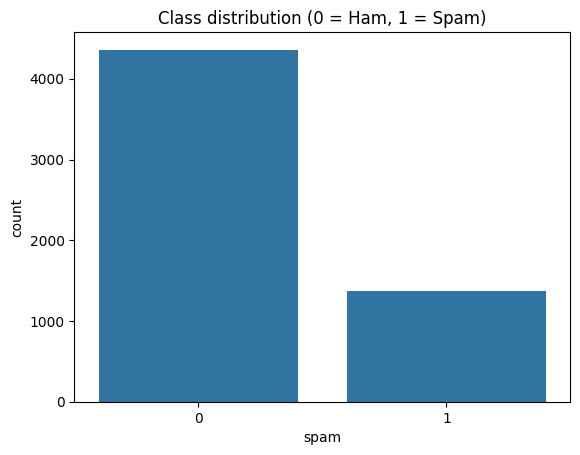

In [ ]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df['spam'].value_counts())

sns.countplot(x='spam', data=df)
plt.title('Class distribution (0 = Ham, 1 = Spam)'); plt.show()

In [ ]:
df = df.dropna().drop_duplicates().reset_index(drop=True)

def clean(t):
    t = t.lower()
    t = re.sub(r'^subject:', '', t.strip())
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean'] = df['text'].apply(clean)
print("BEFORE:", df['text'][0][:150])
print("AFTER :", df['clean'][0][:150])

BEFORE: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the informa
AFTER : naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwh


In [ ]:
from sklearn.model_selection import train_test_split

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['clean'], df['spam'], test_size=0.2, random_state=42, stratify=df['spam'])
y_train, y_test = y_train.values, y_test.values
print("Train:", len(X_train_txt), " Test:", len(X_test_txt))

Train: 4556  Test: 1139


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), min_df=2)
X_train = tfidf.fit_transform(X_train_txt)
X_test  = tfidf.transform(X_test_txt)
print(X_train.shape, X_test.shape)

(4556, 5000) (1139, 5000)


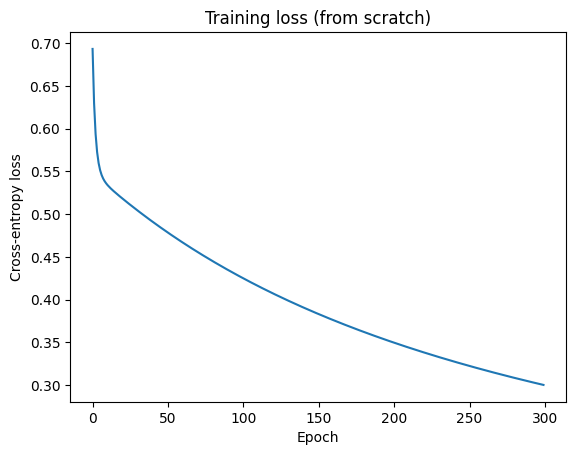

In [ ]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

class LogisticRegressionScratch:
    def __init__(self, lr=1.0, epochs=300, l2=1e-4):
        self.lr, self.epochs, self.l2, self.losses = lr, epochs, l2, []
    def fit(self, X, y):
        m, n = X.shape
        self.w, self.b = np.zeros(n), 0.0
        for _ in range(self.epochs):
            p = sigmoid(X @ self.w + self.b)
            self.losses.append(-np.mean(y*np.log(p+1e-12) + (1-y)*np.log(1-p+1e-12)))
            self.w -= self.lr * (X.T @ (p - y) / m + self.l2 * self.w)
            self.b -= self.lr * np.mean(p - y)
        return self
    def predict_proba(self, X): return sigmoid(X @ self.w + self.b)
    def predict(self, X, thr=0.5): return (self.predict_proba(X) >= thr).astype(int)

scratch = LogisticRegressionScratch().fit(X_train, y_train)

plt.plot(scratch.losses)
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.title('Training loss (from scratch)'); plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(LogisticRegression(max_iter=1000), {'C': [0.1, 1, 10, 100]}, scoring='f1', cv=5)
grid.fit(X_train, y_train)
print("Best C:", grid.best_params_, "| CV F1:", round(grid.best_score_, 4))
lr = grid.best_estimator_

Best C: {'C': 100} | CV F1: 0.983


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (from scratch),0.8665,1.0000,0.4453,0.6162,0.9978
1,Logistic Regression (sklearn),0.9912,0.9853,0.9781,0.9817,0.9997


              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       865
        Spam       0.99      0.98      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



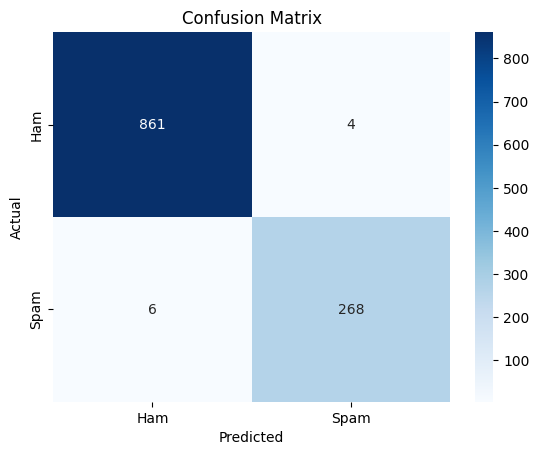

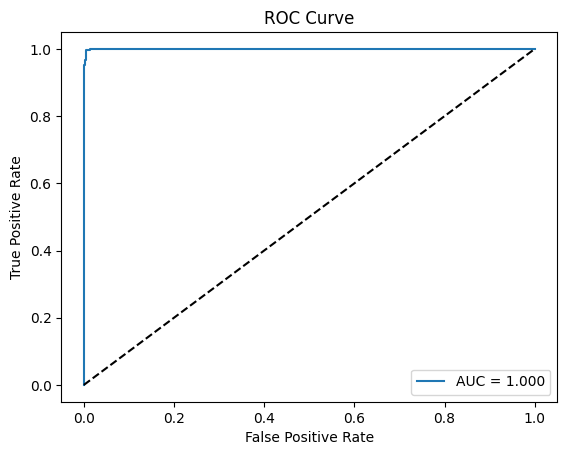

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

prob = lr.predict_proba(X_test)[:, 1]
pred = lr.predict(X_test)

models = {'Logistic Regression (from scratch)': (scratch.predict(X_test), scratch.predict_proba(X_test)),
          'Logistic Regression (sklearn)': (pred, prob)}
rows = [[n, accuracy_score(y_test, p), precision_score(y_test, p), recall_score(y_test, p),
         f1_score(y_test, p), roc_auc_score(y_test, pr)] for n, (p, pr) in models.items()]
display(pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC']).round(4))

print(classification_report(y_test, pred, target_names=['Ham','Spam']))

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()

fpr, tpr, _ = roc_curve(y_test, prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, prob):.3f}'); plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.show()

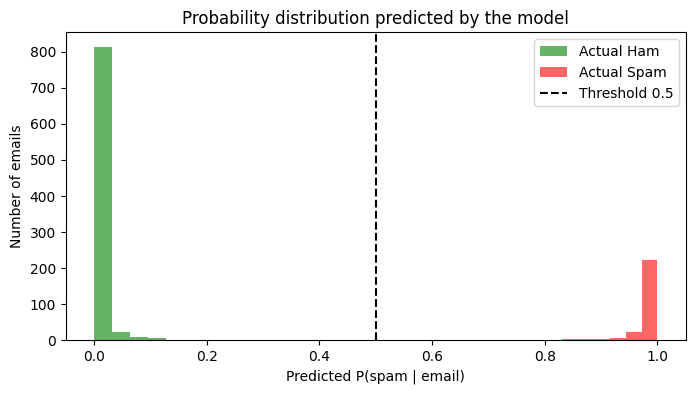

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(prob[y_test == 0], bins=30, alpha=0.6, label='Actual Ham', color='green')
plt.hist(prob[y_test == 1], bins=30, alpha=0.6, label='Actual Spam', color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted P(spam | email)'); plt.ylabel('Number of emails')
plt.title('Probability distribution predicted by the model'); plt.legend(); plt.show()

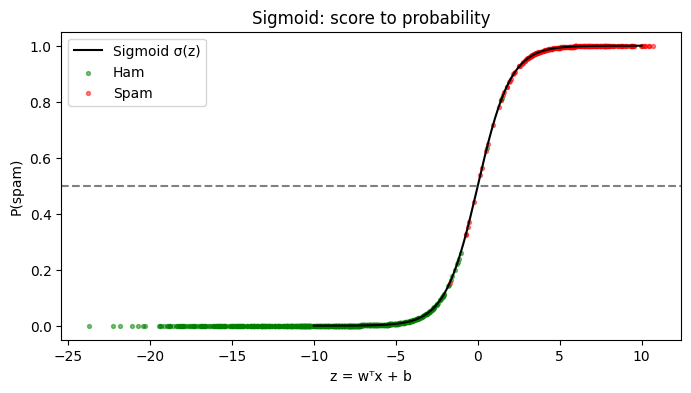

In [ ]:
z = lr.decision_function(X_test)
zs = np.linspace(-10, 10, 200)
plt.figure(figsize=(8,4))
plt.plot(zs, 1/(1+np.exp(-zs)), 'k', label='Sigmoid σ(z)')
plt.scatter(z[y_test==0], prob[y_test==0], s=8, c='green', alpha=0.5, label='Ham')
plt.scatter(z[y_test==1], prob[y_test==1], s=8, c='red', alpha=0.5, label='Spam')
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel('z = wᵀx + b'); plt.ylabel('P(spam)'); plt.title('Sigmoid: score to probability'); plt.legend(); plt.show()

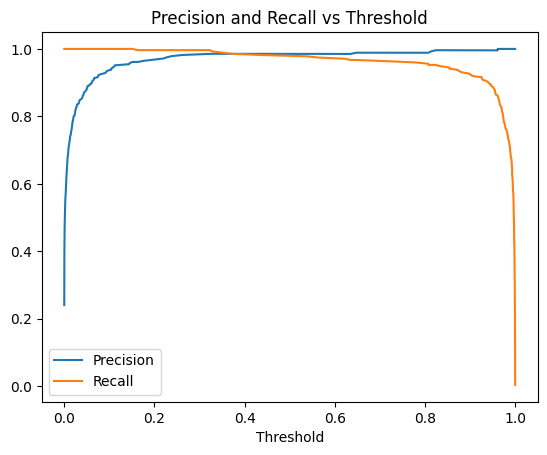

In [ ]:
from sklearn.metrics import precision_recall_curve
p, r, t = precision_recall_curve(y_test, prob)
plt.plot(t, p[:-1], label='Precision'); plt.plot(t, r[:-1], label='Recall')
plt.xlabel('Threshold'); plt.title('Precision and Recall vs Threshold'); plt.legend(); plt.show()

In [ ]:
feat = np.array(tfidf.get_feature_names_out()); coef = lr.coef_[0]
print("Top SPAM features:", list(feat[np.argsort(coef)[-12:][::-1]]))
print("Top HAM features :", list(feat[np.argsort(coef)[:12]]))

for thr in [0.3, 0.5, 0.7, 0.9]:
    pr_ = (prob >= thr).astype(int)
    print(f"threshold={thr}: precision={precision_score(y_test, pr_):.4f}  recall={recall_score(y_test, pr_):.4f}")

def predict_email(text):
    p = lr.predict_proba(tfidf.transform([clean(text)]))[0, 1]
    return f"P(spam) = {p:.3f} -> {'SPAM' if p >= 0.5 else 'HAM'}"

print(predict_email("Congratulations! You won a free prize, click here now to claim money"))
print(predict_email("Hi team, please find attached the agenda for tomorrow's project meeting"))

Top SPAM features: ['click', 'life', 'account', 'money', 'viagra', 'software', 'http', 'free', 'man', 'sex', 'low', 'online']
Top HAM features : ['enron', 'vince', 'ect', 'thanks', 'research', 'energy', 'kaminski', 'model', 'password', 'attached', 'houston', 'let know']
threshold=0.3: precision=0.9856  recall=0.9964
threshold=0.5: precision=0.9853  recall=0.9781
threshold=0.7: precision=0.9888  recall=0.9635
threshold=0.9: precision=0.9961  recall=0.9234
P(spam) = 0.999 -> SPAM
P(spam) = 0.000 -> HAM


In [ ]:
def check_email(text, thr=0.5):
    v = tfidf.transform([clean(text)])
    p = lr.predict_proba(v)[0, 1]
    label = "SPAM" if p >= thr else "NOT SPAM (HAM)"
    print(f"\nP(spam) = {p:.3f}   P(ham) = {1-p:.3f}   ->  {label}")

    # which words influenced the decision
    contrib = v.toarray()[0] * lr.coef_[0]
    order = np.argsort(contrib)
    print("Words pushing towards SPAM:", [feat[i] for i in order[::-1][:5] if contrib[i] > 0])
    print("Words pushing towards HAM :", [feat[i] for i in order[:5] if contrib[i] < 0])

while True:
    text = input("\nPaste an email (one line) or type 'quit': ")
    if text.strip().lower() == 'quit':
        break
    check_email(text)


P(spam) = 1.000   P(ham) = 0.000   ->  SPAM
Words pushing towards SPAM: ['click', 'money', 'claim']
Words pushing towards HAM : []
